This notebook is a toy example of use case for GRNgen graph ensemble.

In this example GRNgen graph ensemble is used to analyze the sensitivity of GENIE3 inference performance to motifs counts present in the the ground truth graph. The experiment follows the following steps:

1) Generation of ensemble of graphs
2) Selection of a subset of graphs facilitating the sensitivity analyis by

    a) Maximizing the standard deviation of a target motif count

    b) Favorizing uniform distribution of the target motif count

    c) Minimizing the standard deviation of the non-target motifs
4) Generate synthetic "gene expression" data for each graphs from the subset of graphs
5) Run GENIE3 inference on the "gene expression" data
6) Analyze the sensitivity of GENIE3 inference performance to the target motif variation

In [25]:
from grngen import *
import pandas as pd
import os
import sys
import json
import networkx as nx
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from GENIE3 import *
from grngen import *
from scipy import sparse
from joblib import Parallel, delayed
import h5py
from pathlib import Path
import random
import time
import io
from contextlib import redirect_stdout
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import re
import gcsfs

# 0) Experiment settings

In [26]:
# specie_list = [
    # 'GSD', 'HSC', 'mCAD', 'VSC', 
    # 'yeast','hESC', 'mESC', 
    # 'ecoli_gnw', 
    # 'human_trrust', 
    # "athaliana_wolf", "dmelanogaster_wolf",  "hsapiens_wolf", "scerevisiae_wolf",
    # "ecoli_wolf",
    # 'mDC'
    # ]

# Input:
config = {}
graph_folder = f"../data/graphs/" # reference graph and associated data folder path
config['specie'] = 'human_trrust'
config['target_feature'] = 'Cascade'

config['n_graphs'] = 100 # Graph ensemble size

config['n_select'] = 10 # Graph subset size
config['properties'] = [ # Remove property if not to be considered in the graph subset selection BUT leave 'graph_id'
    'graph_id',
    'Bi-Mutual',
    'Cascade', 
    'Clique',
    'FBL',
    'FFL',
    'Fan-In',
    'Fan-Out',
    'Mutual-Cascade',
    'Mutual-In', 
    'Mutual-Out',
    'Regulated-Mutual', 
    'Regulating-Mutual', 
    'Semi-Clique'
]

config['nthreads'] = os.cpu_count()-1
config['n_sims'] = 100 # Number of simulation per graph
config['init_con_seed'] = 1 # Seed for simulation
config['n_steps'] = 4000 # Simulation timestep at which we take a snapshot of the simulation as a "gene expression" vector


config['genie3'] = {}
config['genie3']['ntrees'] = 100
config['genie3']['K'] = 'sqrt'
config['iterations'] = 1 # Number of inference iteration


config['feature_list'] = ['Bi-Mutual', 'Cascade', 
                          'Clique', 'FBL', 'FFL', 
                          'Fan-In',
                          'Fan-Out', 'Mutual-Cascade', 'Mutual-In', 'Mutual-Out',
                          'Regulated-Mutual', 'Regulating-Mutual', 'Semi-Clique']

# ====================== Create data output structure ====================================
# Output:
graph_ensemble_dir = f"../data/example/generation/"
if not os.path.exists(graph_ensemble_dir):
    os.makedirs(graph_ensemble_dir)
config['parquet_folder'] = f'{graph_ensemble_dir}graph_ensemble.parquet'

graph_subset_folder = f"../data/example/selection/"
if not os.path.exists(graph_subset_folder):
    os.makedirs(graph_subset_folder)
graph_subset_file = f"{graph_subset_folder}selected_ids.txt"

config['sim_folder'] = f"../data/example/simulation/"
if not os.path.exists(config['sim_folder']):
    os.makedirs(config['sim_folder'])
simfile = f"{config['sim_folder']}sim.parquet"

inference_dir = f"../data/example/inference/"
if not os.path.exists(inference_dir):
    os.makedirs(inference_dir)

sensi_dir = f"../data/example/sensitivity_analysis/"
if not os.path.exists(sensi_dir):
    os.makedirs(sensi_dir)

# 1) Generation of graph ensemble

In [6]:
ground_truth_graph, _, _ = load_graphs(graph_folder+config['specie'])
node_degree_sequence = get_node_degrees(ground_truth_graph)
df = generate_random_graphs(
        config['n_graphs'],
        node_degree_sequence,
        config['parquet_folder'],
        config['specie'],
        n_jobs=config['nthreads'],
        connect_type='random',
        method='grngen'
    )

Loaded graph from ../data/graphs/human_trrust_g.graphml
Loaded graph stats from ../data/graphs/human_trrust_stat.json
Loaded graph motif counts from ../data/graphs/human_trrust_motifs.json


Generating human_trrust ensemble: 100%|██████████| 100/100 [00:49<00:00,  2.02it/s]


Successfully saved 100 graphs to ../data/example/generation/graph_ensemble.parquet


# 2) Selection of graph subset

Selecting graphs: 100%|██████████| 10/10 [00:03<00:00,  3.28it/s]



 Target Column 'Cascade':
   Variance:
   Original variance: 1974296.3572
   Selected variance: 4815657.1111
   Ratio: 243.92%

   Original variance normalized: 0.0456
   Selected variance normalized: 0.1113
   Ratio normalized: 243.92%

   Standard Deviation:
   Original standard deviation: 1405.0966
   Selected standard deviation: 2194.4606
   Ratio: 156.18%

   Original standard deviation normalized: 0.2136
   Selected standard deviation normalized: 0.3337
   Ratio normalized: 156.18%

 Other Columns:
   Variance:
   Original: 218928.3791
   Selected: 293380.9602
   Reduction: -34.01%

   Original normalized: 0.0435
   Selected normalized: 0.0335
   Reduction normalized: 23.11%

   Standard Deviation:
   Original: 254.1743
   Selected: 272.3110
   Reduction: -7.14%

   Original normalized: 0.2080
   Selected normalized: 0.1714
   Reduction normalized: 17.60%


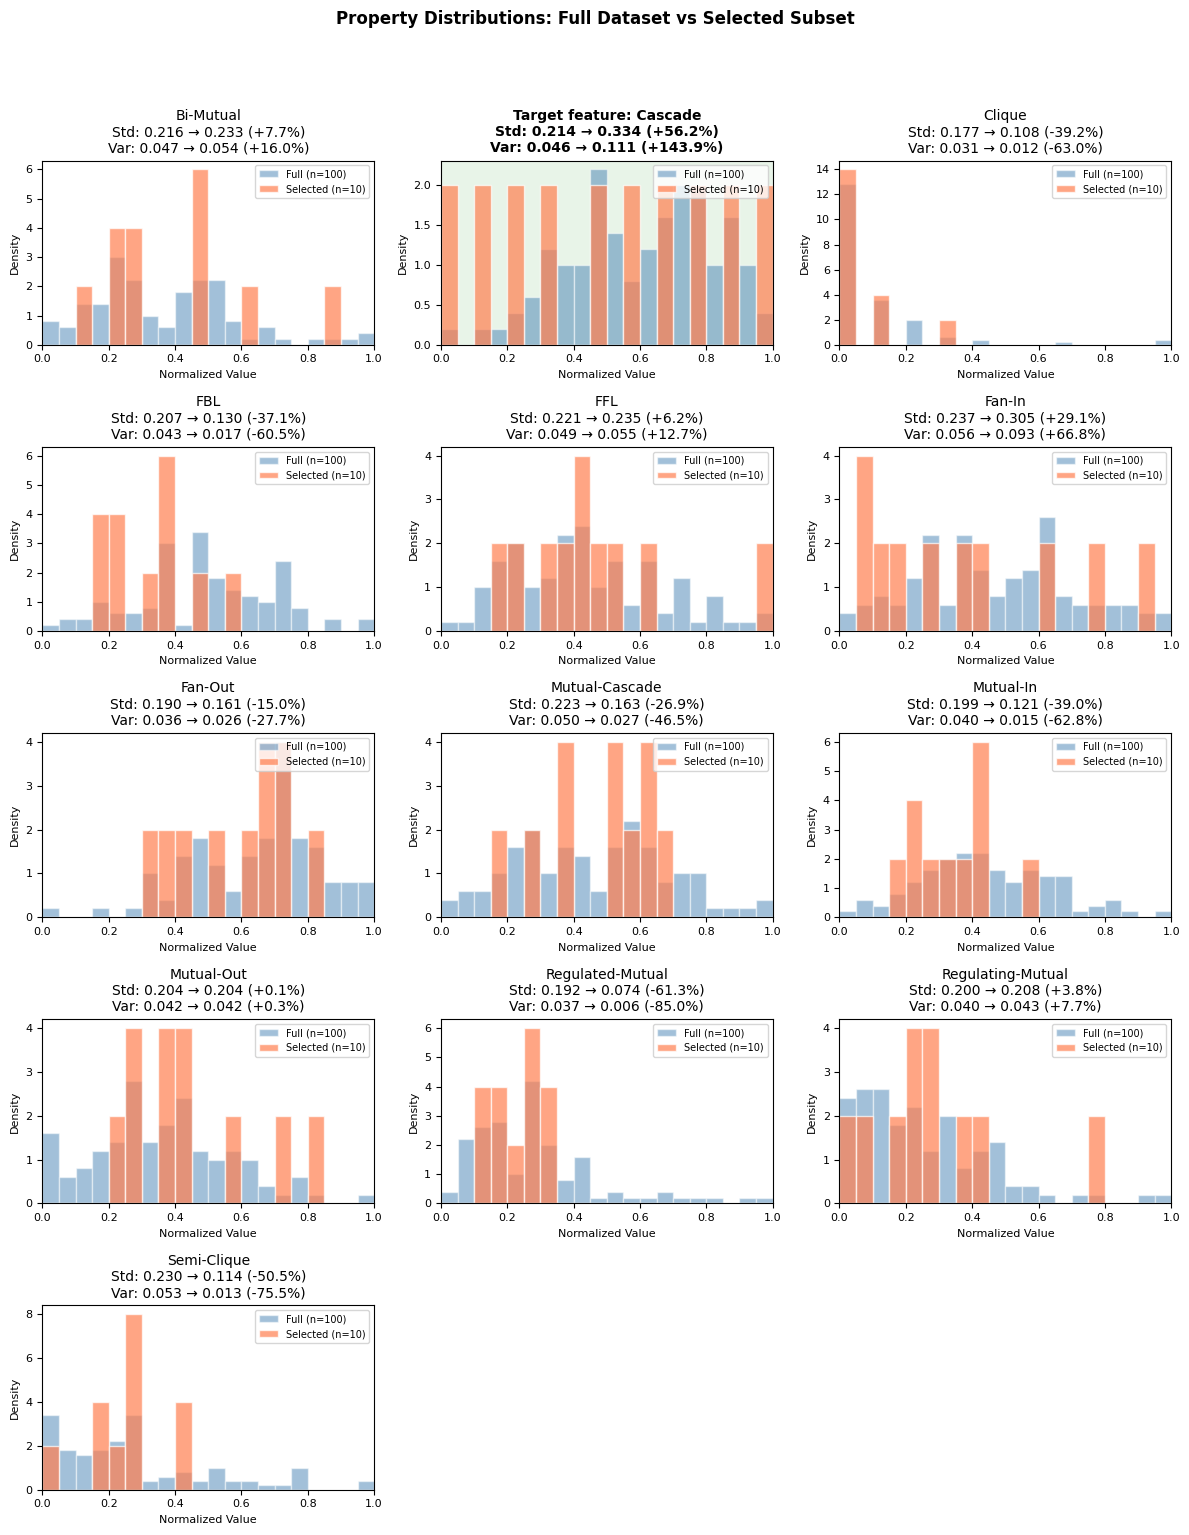

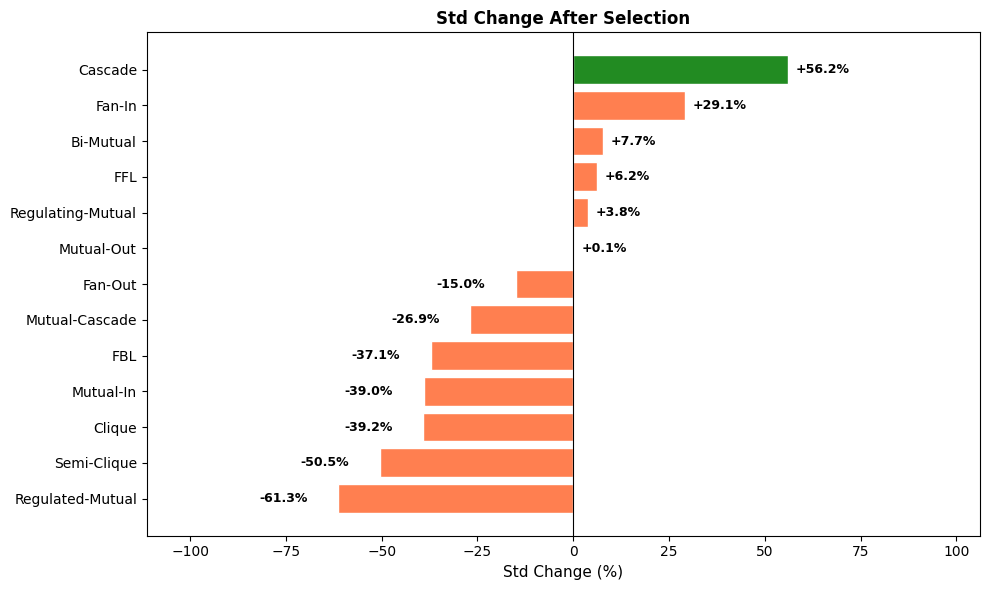

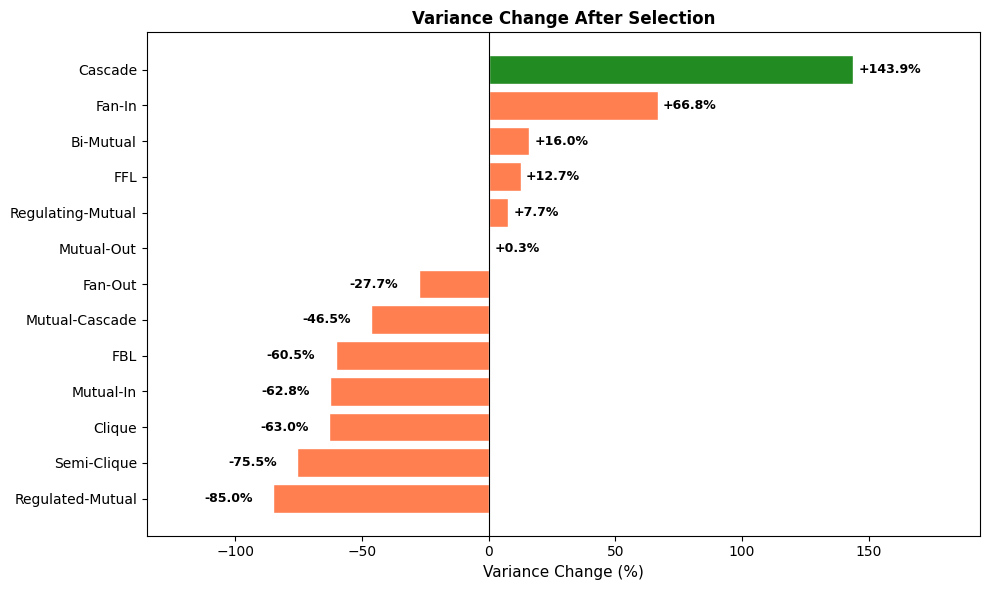

In [7]:
#loading function
df = pd.read_parquet(config['parquet_folder'], columns=config['properties'])

n_select = 10

stat='std'
selected_ids_std, selected_df_std, selected_df_normalized = select_optimal_graphs(
    df, 
    n_select=n_select,
    target_feature=config['target_feature'],
    feature_cols=config['properties'],
    alpha=1,   # Weight for maximizing target spread
    beta=1,    # Weight for minimizing other spread
    gamma=1,    # Weight for uniform distribution
    stat='std'
)


np.savetxt(graph_subset_file, 
       selected_ids_std, 
       delimiter=",",
       fmt='%d')

selected_ids_std = np.loadtxt(graph_subset_file,
                      delimiter=",",
                     dtype=int)


evaluate_selection(df, selected_ids_std, config['target_feature'])

# Plot histograms
fig3 = plot_hist_comparison(
    df, 
    selected_ids_std, 
    target_feature=config['target_feature'],  # or None for auto-detect
    n_cols=3,
    save_path=f"{graph_subset_folder}hist_compare.png"
)

# Plot summary bar chart
fig4 = plot_std_summary(
    df, 
    selected_ids_std,
    target_feature=config['target_feature'],
    save_path=f"{graph_subset_folder}std_summary.png"
)

fig5 = plot_var_summary(
    df, 
    selected_ids_std,
    target_feature=config['target_feature'],
    save_path=f"{graph_subset_folder}var_summary.png"
)

# 3) Simulation

In [22]:
config['graph_id_list'] = np.loadtxt(graph_subset_file, dtype=int).tolist()
graphs = load_graphs_from_parquet(config['parquet_folder'], graph_ids=config['graph_id_list'])

records = []
for graph_id in tqdm(graphs.keys(), desc="Processing graphs"):
# for graph_id in graphs.keys():
    graph = graphs[graph_id]
    adj = nx.adjacency_matrix(graph)
    adj_mx = randomize_edge_signs(adj, prob_inhibitor=0.4)
    
    if sparse.issparse(adj_mx):
        adj_mx = adj_mx.toarray()

    final_states, x0_states = simulate_multi_bool_parallel(
        adj_mx, 
        base_seed=config['init_con_seed'], 
        n_sims=config['n_sims'], 
        n_steps=config['n_steps'],
        n_jobs=config['nthreads']
    )
    
    records.append({
        'graph_id': graph_id,
        'final_states': final_states.tobytes(),
        'x0_states': x0_states.tobytes(),
        'final_shape': final_states.shape,
        'x0_shape': x0_states.shape,
        'init_con_seed': config['init_con_seed'],
        'n_steps': config['n_steps']
    })

pd.DataFrame(records).to_parquet(simfile, index=False, compression='snappy')

Processing graphs:   0%|          | 0/10 [00:00<?, ?it/s]/opt/micromamba/envs/venv_trajinf/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.21) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/opt/micromamba/envs/venv_trajinf/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.21) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/opt/micromamba/envs/venv_t

# 4) Inference

In [24]:
def load_simulation(parquet_file, graph_id):
    """Load and reconstruct simulation data for a single graph"""
    row = pd.read_parquet(
        parquet_file,
        filters=[('graph_id', '==', graph_id)]
    ).iloc[0]
    
    final_states = np.frombuffer(
        row['final_states'], 
        dtype=np.uint8
    ).reshape(tuple(row['final_shape']))
    
    x0_states = np.frombuffer(
        row['x0_states'], 
        dtype=np.uint64
    ).reshape(tuple(row['x0_shape']))
    
    return final_states, x0_states

def silent_GENIE3(*args, **kwargs):
    """Run GENIE3 without print statements"""
    with redirect_stdout(io.StringIO()):
        return GENIE3(*args, **kwargs)
        

start_time = time.time()
computation_times = {}

for graph_id in tqdm(graphs.keys(), desc="Processing graphs", total=len(graphs)):
    graph_start = time.time()
    
    final_states, x0_states = load_simulation(simfile, graph_id)
    # Load grount truth graph
    adj_mx = nx.adjacency_matrix(graphs[graph_id])

    # Init output file names
    inferred_adj_mx_file = f"{inference_dir}inf_adj_mx_vim_ntrees_graphid{graph_id}.npz"
    inferred_edge_list_file = f"{inference_dir}inf_edge_links_ntrees_graphid{graph_id}.csv"

    # Inference
    gene_names = [f"G{i}" for i in range(final_states.shape[1])]
    ## Inferred adj mx
    inferred_adj_mx = silent_GENIE3(final_states, gene_names=gene_names, 
                             ntrees=config['genie3']['ntrees'], 
                             K=config['genie3']['K'], 
                             nthreads=config['nthreads'])
    np.savez_compressed(inferred_adj_mx_file, 
                        inferred_adj_mx=inferred_adj_mx, 
                        gene_names=gene_names)
    ## Edge list
    inferred_edge_list = get_link_list(inferred_adj_mx, 
                                       gene_names=gene_names,
                                       file_name=inferred_edge_list_file)
    computation_times[graph_id] = time.time() - graph_start

    #######################################################

config['time_per_graph'] = computation_times

end_time = time.time()
computation_time = end_time - start_time
config['time'] = computation_time

with open(f"../configs/config_example.json", "w") as f:
        json.dump(config, f)
    

Processing graphs: 100%|██████████| 10/10 [05:41<00:00, 34.14s/it]


# 5) Senstivity Analysis

Loading ../configs/config_example.json


Processing graphs: 100%|██████████| 10/10 [00:25<00:00,  2.56s/it]


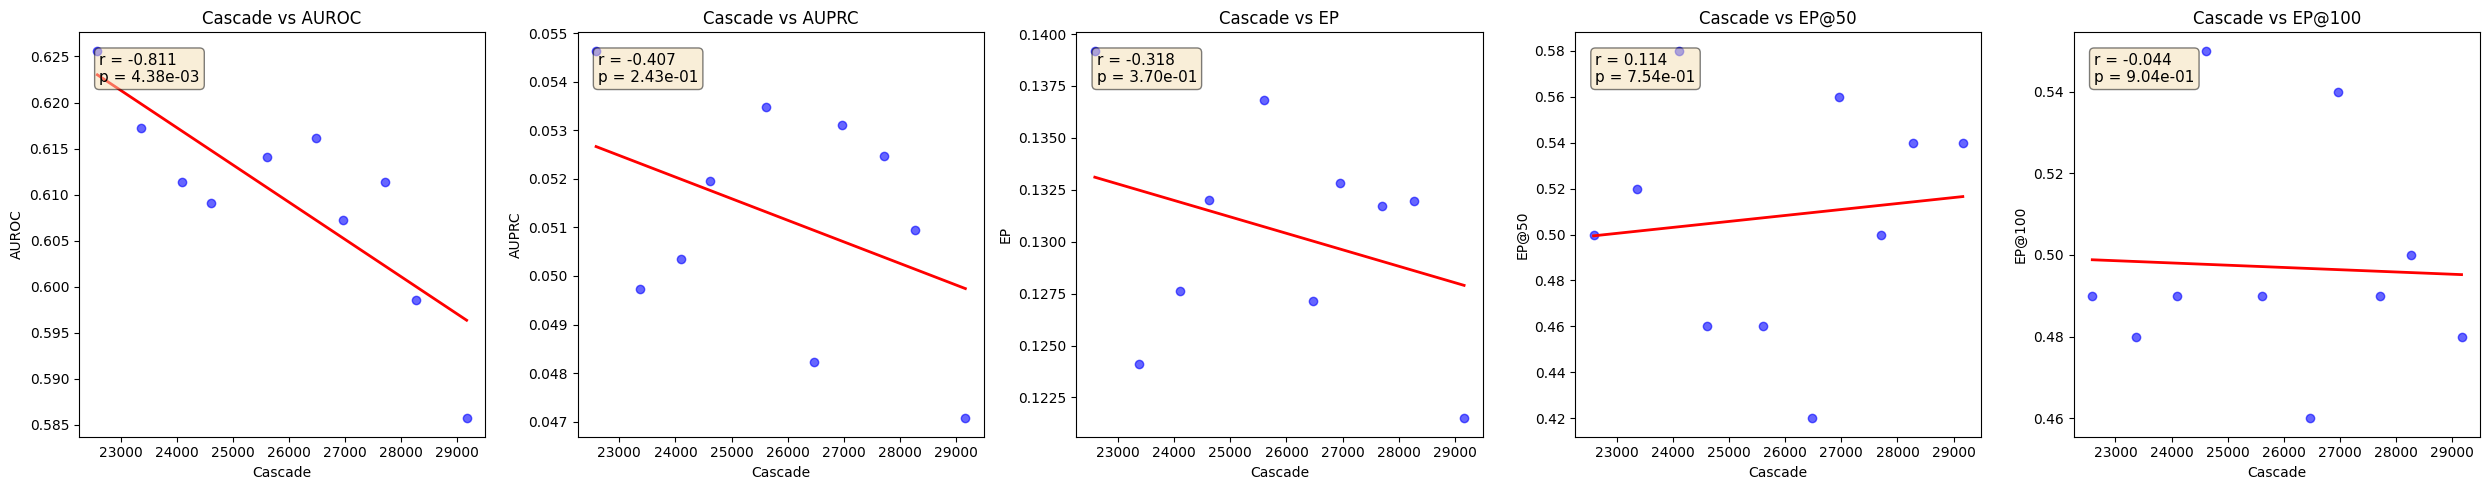

In [27]:
# Thresholds of edge rank to compute early precision
K1 = 50 
K2 = 100

config_file = f"../configs/config_example.json"
print(f"Loading {config_file}")
with open(config_file) as f:
    config = json.load(f)

df_sensi = pd.read_parquet(
    config['parquet_folder'],
    columns=['graph_id', config['target_feature']],
    filters=[('graph_id', 'in', config['graph_id_list'])]
)

results = []

for graph_id in tqdm(graphs.keys(), desc="Processing graphs"):
    inf_adj_mx_file = f"{inference_dir}inf_adj_mx_vim_ntrees_graphid{graph_id}.npz"
    inf_adj_mx = np.load(inf_adj_mx_file, allow_pickle=True)
    auroc, auprc, ep, ep_k1, ep_k2 = evaluate_inference_epr(
        nx.adjacency_matrix(graphs[graph_id]), 
        inf_adj_mx['inferred_adj_mx'],
        k1=K1,
        k2=K2
    )

    results.append({
        'graph_id': graph_id, 
        'AUROC': auroc, 
        'AUPRC': auprc, 
        'EP': ep,
        f'EP@{K1}': ep_k1,
        f'EP@{K2}': ep_k2
    })

results_df = pd.DataFrame(results).set_index('graph_id')
df_sensi = df_sensi.set_index('graph_id')
df_sensi = df_sensi.join(results_df, how='left')

df_sensi.to_csv(f"{inference_dir}inference_metrics.csv")

# Plot
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
scatter_with_correlation(df_sensi, config['target_feature'], 'AUROC', ax=axes[0])
scatter_with_correlation(df_sensi, config['target_feature'], 'AUPRC', ax=axes[1])
scatter_with_correlation(df_sensi, config['target_feature'], 'EP', ax=axes[2])
scatter_with_correlation(df_sensi, config['target_feature'], f'EP@{K1}', ax=axes[3])
scatter_with_correlation(df_sensi, config['target_feature'], f'EP@{K2}', ax=axes[4])
plt.tight_layout()
plt.savefig(f"{sensi_dir}inference_metric.png", format='png')
plt.show()